# 바나프레소 입지 적합도 지표
전처리 → 피처 엔지니어링 → Rule-based Filter → Scoring → 시각화


---
## 1. 환경설정
라이브러리, 경로 설정

In [1]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [2]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

from shapely.geometry import Point
from scipy.spatial import cKDTree

# 한글 폰트 설정
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정
DATA_DH   = '/Users/danha/Desktop/IT/project/team_project_brew_map/universe_git/data/dh/'
DATA_MJ   = '/Users/danha/Desktop/IT/project/team_project_brew_map/universe_git/data/mj/'   
DATA_SA   = '/Users/danha/Desktop/IT/project/team_project_brew_map/universe_git/data/sa/seoul_data/'

print('라이브러리 로드 완료')

라이브러리 로드 완료


---
## 2. 데이터 로드
전처리된 데이터 불러오기

In [4]:
# 교통 
bus_stop   = pd.read_csv(DATA_DH + 'bus_stop.csv',   encoding='utf-8-sig')
crosswalk  = pd.read_csv(DATA_DH + 'crosswalk.csv',  encoding='utf-8-sig')
road       = pd.read_csv(DATA_DH + 'road.csv',       encoding='utf-8-sig')
station    = pd.read_csv(DATA_DH + 'station.csv',    encoding='utf-8-sig')

# 상권 
cafe           = pd.read_csv(DATA_MJ + 'cafe.csv',           encoding='utf-8-sig')
industry_center= pd.read_csv(DATA_MJ + 'industry_center.csv',encoding='utf-8-sig')
flpop_a        = pd.read_csv(DATA_MJ + 'flpop_a.csv',        encoding='utf-8-sig')  # 집계구 유동인구
flpop_t        = pd.read_csv(DATA_MJ + 'flpop_t.csv',        encoding='utf-8-sig')  # 시간대별 유동인구

# 직방 매물
listing = pd.read_csv(DATA_MJ + 'listing.csv', encoding='utf-8-sig')

# 생활 인프라 
academy  = pd.read_csv(DATA_SA + 'academy_df.csv',  encoding='utf-8-sig')
gym      = pd.read_csv(DATA_SA + 'gym_df.csv',      encoding='utf-8-sig')
hospital = pd.read_csv(DATA_SA + 'hospital_df.csv', encoding='utf-8-sig')
physical = pd.read_csv(DATA_SA + 'physical_df.csv', encoding='utf-8-sig')
school   = pd.read_csv(DATA_SA + 'school.csv',      encoding='utf-8-sig')

print('데이터 로드 완료')
print(f'직방 매물 수: {len(listing):,}건')

데이터 로드 완료
직방 매물 수: 1,319건


## 3. 직방 매물 데이터 정제

크롤링된 raw 데이터에서 좌표, 보증금, 월세, 면적을 숫자형으로 변환하고 이상치를 제거

In [5]:
print('직방 매물 컬럼 확인')
print(listing.columns.tolist())
print(listing.head(3))

직방 매물 컬럼 확인
['listing_id', 'addr', '위도', '경도', 'business_type', 'transaction_type', 'sale_price', 'key_money', '보증금', '월세', 'maintenance_fee', '면적', 'floor', 'flpop_type', 'trdar_cd', 'adstrd_cd']
   listing_id           addr         위도          경도 business_type  \
0      575115  서울특별시 강남구 논현동  37.519306  127.029262           사무실   
1      703777  서울특별시 서초구 잠원동  37.511775  127.020540         카페/커피   
2      701846  서울특별시 강남구 논현동  37.512658  127.021577           사무실   

  transaction_type  sale_price  key_money       보증금       월세  maintenance_fee  \
0               월세           0          0  30000000  2000000                0   
1               월세           0   40000000  50000000  3000000                0   
2               월세           0          0  35000000  3000000                0   

      면적 floor flpop_type  trdar_cd  adstrd_cd  
0  82.60    4층          T   3120190   11680531  
1  33.06    1층          T   3120185   11650540  
2  49.59    2층          T   3120185   11680521  


In [6]:
# 문자열에서 숫자만 추출
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str).str.replace(r'[^0-9.]', '', regex=True),
        errors='coerce'
    )

for col in ['보증금', '월세', '면적']:  # 실제 컬럼명으로 수정
    if col in listing.columns:
        listing[col] = clean_numeric(listing[col])

# 좌표 결측 제거 (결측없음)
lat_col = [c for c in listing.columns if 'lat' in c.lower() or '위도' in c]
lng_col = [c for c in listing.columns if 'lng' in c.lower() or 'lon' in c.lower() or '경도' in c]

if lat_col and lng_col:
    listing.rename(columns={lat_col[0]: '위도', lng_col[0]: '경도'}, inplace=True)
    listing = listing.dropna(subset=['위도', '경도'])
    listing['위도'] = listing['위도'].astype(float)
    listing['경도'] = listing['경도'].astype(float)
    # 서울 범위 필터
    listing = listing[
        (listing['위도'].between(37.4, 37.7)) &
        (listing['경도'].between(126.7, 127.2))
    ].reset_index(drop=True)

print(f'정제 후 매물 수: {len(listing):,}건')
listing.head(3)

정제 후 매물 수: 1,319건


,listing_id,addr,위도,경도,business_type,transaction_type,sale_price,key_money,보증금,월세,maintenance_fee,면적,floor,flpop_type,trdar_cd,adstrd_cd
0,575115,서울특별시 강남구 논현동,37.519306,127.029262,사무실,월세,0,0,30000000,2000000,0,82.60,4층,T,3120190,11680531
1,703777,서울특별시 서초구 잠원동,37.511775,127.020540,카페/커피,월세,0,40000000,50000000,3000000,0,33.06,1층,T,3120185,11650540
2,701846,서울특별시 강남구 논현동,37.512658,127.021577,사무실,월세,0,0,35000000,3000000,0,49.59,2층,T,3120185,11680521


## 4. Rule-based Hard Filter

바나프레소 출점 기준에 맞지 않는 매물 사전 제거

시작 매물 수: 1,319건

  [보증금 5,000만원 이하] 제거: 387건  →  잔여: 932건
  [월세 300만원 이하] 제거: 261건  →  잔여: 671건
  [면적 33~83㎡ (10~25평)] 제거: 317건  →  잔여: 354건
  [환산보증금 9억원 이하] 제거: 0건  →  잔여: 354건

최종 필터 후 매물: 1,319 → 354건  (73.2% 제거)


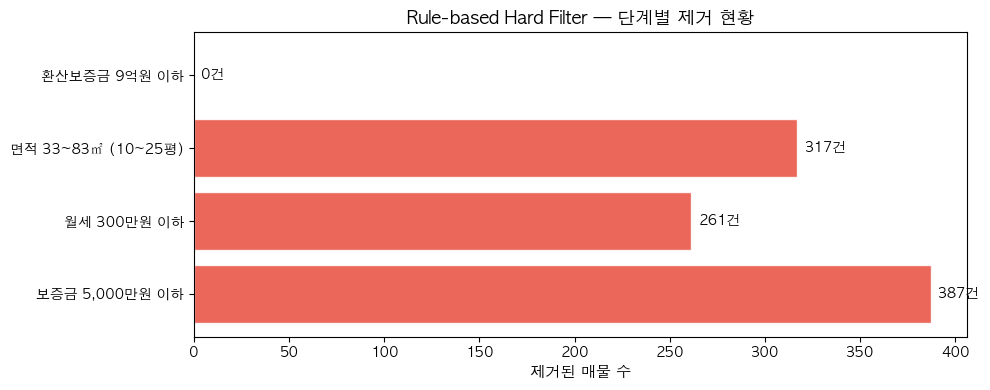

In [7]:
original_count = len(listing)

DEPOSIT_MAX  = 50_000_000   
MONTHLY_MAX  =  3_000_000  
AREA_MIN     = 33.0          # 10평 = 약 33㎡
AREA_MAX     = 83.0          # 25평 = 약 83㎡

filtered = listing.copy()
log = {}

def apply_filter(df, mask, label):
    before = len(df)
    df = df[mask].reset_index(drop=True)
    log[label] = before - len(df)
    print(f'  [{label}] 제거: {before - len(df):,}건  →  잔여: {len(df):,}건')
    return df

print(f'시작 매물 수: {len(filtered):,}건\n')


if '보증금' in filtered.columns:
    filtered = apply_filter(
        filtered,
        filtered['보증금'].fillna(0) <= DEPOSIT_MAX,
        f'보증금 {DEPOSIT_MAX//10000:,}만원 이하'
    )


if '월세' in filtered.columns:
    filtered = apply_filter(
        filtered,
        filtered['월세'].fillna(0) <= MONTHLY_MAX,
        f'월세 {MONTHLY_MAX//10000:,}만원 이하'
    )

if '면적' in filtered.columns:
    filtered = apply_filter(
        filtered,
        filtered['면적'].between(AREA_MIN, AREA_MAX),
        f'면적 {AREA_MIN:.0f}~{AREA_MAX:.0f}㎡ (10~25평)'
    )


if '보증금' in filtered.columns and '월세' in filtered.columns:
    filtered['환산보증금'] = (
        filtered['보증금'].fillna(0) +
        filtered['월세'].fillna(0) * 100
    )

    filtered = apply_filter(
        filtered,
        filtered['환산보증금'] <= 900_000_000,
        '환산보증금 9억원 이하'
    )

print(f'\n최종 필터 후 매물: {original_count:,} → {len(filtered):,}건  '
      f'({(1-len(filtered)/original_count)*100:.1f}% 제거)')


if log:
    fig, ax = plt.subplots(figsize=(10, 4))
    labels, values = list(log.keys()), list(log.values())
    bars = ax.barh(labels, values, color='#e74c3c', edgecolor='white', alpha=0.85)

    for bar, val in zip(bars, values):
        if max(values) > 0:
            ax.text(bar.get_width() + max(values)*0.01,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:,}건',
                    va='center',
                    fontsize=10)

    ax.set_xlabel('제거된 매물 수', fontsize=11)
    ax.set_title('Rule-based Hard Filter — 단계별 제거 현황', fontsize=13)
    plt.tight_layout()
    plt.show()

## 5. 피처 엔지니어링

각 매물 위치에서 반경 300미터 이내의 시설 수를 집계하여 입지 피처를 만들기
**cKDTree**를 사용해 빠르게 근접 탐색

target_df의 각 매물 에서 반경 radius_m 내 ref_df 시설 수를 반환

위경도 → 미터 변환: 위도 1도 ≈ 111,000m 사용 (서울 기준 근사치)

In [8]:
def count_within_radius(target_df, ref_df, lat_col_ref, lng_col_ref, radius_m=300):
    
    # 좌표 존재 여부 확인
    ref_lat = [c for c in ref_df.columns if 'lat' in c.lower() or '위도' in c]
    ref_lng = [c for c in ref_df.columns if 'lng' in c.lower() or 'lon' in c.lower() or '경도' in c]
    
    if not ref_lat or not ref_lng:
        print(f'  좌표 컬럼 없음, 건너뜀')
        return np.zeros(len(target_df))
    
    ref_lat_col = ref_lat[0]
    ref_lng_col = ref_lng[0]
    
    ref_clean = ref_df[[ref_lat_col, ref_lng_col]].dropna().astype(float)
    
    # 라디안 변환 후 BallTree or 미터 근사
    # 서울 중심 위도 37.56 기준 경도 1도 ≈ 88,800m
    scale_lat = 111000
    scale_lng = 88800
    
    ref_coords = np.column_stack([
        ref_clean[ref_lat_col].values * scale_lat,
        ref_clean[ref_lng_col].values * scale_lng
    ])
    
    target_coords = np.column_stack([
        target_df['위도'].values * scale_lat,
        target_df['경도'].values * scale_lng
    ])
    
    tree = cKDTree(ref_coords)
    counts = tree.query_ball_point(target_coords, r=radius_m, return_length=True)
    return np.array(counts)

print('피처 엔지니어링 함수 준비 완료')

피처 엔지니어링 함수 준비 완료


In [9]:
# 각 시설별 반경 집계

feature_config = [
    ('버스정류장_300m',  bus_stop,        'lat', 'lng', 300),
    ('지하철역_300m',    station,         'lat', 'lng', 300),
    ('횡단보도_300m',    crosswalk,       'lat', 'lng', 300),
    ('카페_300m',        cafe,            'lat', 'lng', 300),
    ('학원_300m',        academy,         'lat', 'lng', 300),
    ('헬스장_300m',      gym,             'lat', 'lng', 300),
    ('병원_300m',        hospital,        'lat', 'lng', 300),
    ('학교_300m',        school,          'lat', 'lng', 300),
    ('피지컬_300m',      physical,        'lat', 'lng', 300),
]

for feat_name, ref_df, lat_c, lng_c, radius in feature_config:
    try:
        filtered[feat_name] = count_within_radius(filtered, ref_df, lat_c, lng_c, radius)
        print(f'  ✓ {feat_name}: 평균 {filtered[feat_name].mean():.1f}개')
    except Exception as e:
        print(f'  ✗ {feat_name} 오류: {e}')
        filtered[feat_name] = 0

print('\n피처 집계 완료')

  ✓ 버스정류장_300m: 평균 5.1개
  ✓ 지하철역_300m: 평균 0.4개
  ✓ 횡단보도_300m: 평균 10.1개
  ✓ 카페_300m: 평균 26.9개
  ✓ 학원_300m: 평균 0.0개
  ✓ 헬스장_300m: 평균 0.0개
  ✓ 병원_300m: 평균 1.5개
  ✓ 학교_300m: 평균 0.2개
  ✓ 피지컬_300m: 평균 0.2개

피처 집계 완료


In [10]:
# 유동인구 매핑: adstrd_cd 기준

print('flpop_a 컬럼:', flpop_a.columns.tolist())
print('stdr_yyqu_cd 값 목록:', sorted(flpop_a['stdr_yyqu_cd'].unique()))


flpop_a 컬럼: ['stdr_yyqu_cd', 'adstrd_cd', 'adstrd_cd_nm', 'tot_flpop_co', 'ml_flpop_co', 'fml_flpop_co', 'agrde_10_flpop_co', 'agrde_20_flpop_co', 'agrde_30_flpop_co', 'agrde_40_flpop_co', 'agrde_50_flpop_co', 'agrde_60_above_flpop_co', 'tmzon_00_06_flpop_co', 'tmzon_06_11_flpop_co', 'tmzon_11_14_flpop_co', 'tmzon_14_17_flpop_co', 'tmzon_17_21_flpop_co', 'tmzon_21_24_flpop_co', 'mon_flpop_co', 'tues_flpop_co', 'wed_flpop_co', 'thur_flpop_co', 'fri_flpop_co', 'sat_flpop_co', 'sun_flpop_co']
stdr_yyqu_cd 값 목록: [np.int64(20191), np.int64(20192), np.int64(20193), np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244), np.int64(20251), np.int64(20252), np.int64(20253)]


In [11]:
# 최신 분기 데이터만 사용 
latest_q = flpop_a['stdr_yyqu_cd'].max()
flpop_latest = flpop_a[flpop_a['stdr_yyqu_cd'] == latest_q].copy()
print(f'사용 분기: {latest_q}  ({len(flpop_latest):,}개 행정동)')

# adstrd_cd 타입 통일 (int) 
flpop_latest['adstrd_cd'] = flpop_latest['adstrd_cd'].astype(int)
filtered['adstrd_cd']     = filtered['adstrd_cd'].astype(int)

# 행정동별 총유동인구 평균 집계 
flpop_agg = (
    flpop_latest
    .groupby('adstrd_cd', as_index=False)['tot_flpop_co']
    .mean()
    .rename(columns={'tot_flpop_co': '유동인구'})
)

# 시간대별 피크 유동인구도 추가 (17~21시 저녁 피크) 
if 'tmzon_17_21_flpop_co' in flpop_latest.columns:
    peak_agg = (
        flpop_latest
        .groupby('adstrd_cd', as_index=False)['tmzon_17_21_flpop_co']
        .mean()
        .rename(columns={'tmzon_17_21_flpop_co': '저녁피크유동인구'})
    )
    flpop_agg = flpop_agg.merge(peak_agg, on='adstrd_cd', how='left')

# listing에 merge 
filtered = filtered.merge(flpop_agg, on='adstrd_cd', how='left')
filtered['유동인구'] = filtered['유동인구'].fillna(0)
if '저녁피크유동인구' in filtered.columns:
    filtered['저녁피크유동인구'] = filtered['저녁피크유동인구'].fillna(0)

print(f'\n유동인구 매핑 완료')
print(f'  매핑 성공: {(filtered["유동인구"] > 0).sum():,}건 / {len(filtered):,}건')
print(f'  평균 유동인구: {filtered["유동인구"].mean():,.0f}')
print(f'  최대 유동인구: {filtered["유동인구"].max():,.0f}')
filtered[['adstrd_cd','유동인구']].dropna().head(5)


사용 분기: 20253  (425개 행정동)

유동인구 매핑 완료
  매핑 성공: 354건 / 354건
  평균 유동인구: 11,046,944
  최대 유동인구: 20,900,630


,adstrd_cd,유동인구
0,11680531,11920183.0
1,11650540,6977070.0
2,11680521,9474796.0
3,11680510,6653298.0
4,11680531,11920183.0


## 6. 입지 점수 산출 

각 피처를 Min-Max 정규화 후 가중합으로 입지 점수 (0~100점)를 계산

In [12]:
# 가중치 설정
WEIGHTS = {
    '유동인구'        : 0.25,
    '지하철역_300m'   : 0.20,   
    '버스정류장_300m' : 0.10,
    '학원_300m'       : 0.10,
    '헬스장_300m'     : 0.08,
    '병원_300m'       : 0.07,
    '카페_300m'       : 0.07,   # 경쟁 지표 → 역가중 적용
    '학교_300m'       : 0.07,
    '횡단보도_300m'   : 0.03,
    '피지컬_300m'     : 0.03,
}
# 역가중 피처: 값이 클수록 점수 감소 (경쟁 강도)
NEGATIVE_FEATS = {'카페_300m'}

print(f'가중치 합계: {sum(WEIGHTS.values()):.2f}')


가중치 합계: 1.00


In [13]:
from sklearn.preprocessing import MinMaxScaler

score_df = filtered.copy()
feature_cols = list(WEIGHTS.keys())

# 존재하는 피처만 사용
available_feats = [f for f in feature_cols if f in score_df.columns]
missing_feats   = [f for f in feature_cols if f not in score_df.columns]
if missing_feats:
    print(f'⚠ 누락 피처 (가중치 재배분됨): {missing_feats}')
print(f'사용 피처 ({len(available_feats)}개): {available_feats}')

# Min-Max 정규화
scaler = MinMaxScaler()
normalized = scaler.fit_transform(score_df[available_feats].fillna(0))
norm_df = pd.DataFrame(normalized, columns=[f'{c}_norm' for c in available_feats])
score_df = pd.concat([score_df.reset_index(drop=True), norm_df], axis=1)

# 가중합 점수 계산 (누락 피처 제외 후 가중치 재정규화)
total_weight = sum(WEIGHTS[f] for f in available_feats)
score = np.zeros(len(score_df))

for feat in available_feats:
    norm_col = f'{feat}_norm'
    w = WEIGHTS[feat] / total_weight
    if feat in NEGATIVE_FEATS:   # 경쟁 지표: 높을수록 불리
        score += w * (1 - score_df[norm_col].values)
    else:
        score += w * score_df[norm_col].values

score_df['입지점수'] = (score * 100).round(1)

# 등급 부여
score_df['등급'] = pd.cut(
    score_df['입지점수'],
    bins=[0, 40, 55, 70, 85, 100],
    labels=['D', 'C', 'B', 'A', 'S'],
    include_lowest=True
)

print('\n=== 입지 점수 통계 ===')
print(score_df['입지점수'].describe().round(2))
print('\n등급 분포:')
print(score_df['등급'].value_counts().sort_index())


사용 피처 (10개): ['유동인구', '지하철역_300m', '버스정류장_300m', '학원_300m', '헬스장_300m', '병원_300m', '카페_300m', '학교_300m', '횡단보도_300m', '피지컬_300m']

=== 입지 점수 통계 ===
count    354.00
mean      29.25
std       14.35
min        8.20
25%       17.20
50%       24.10
75%       40.40
max       65.10
Name: 입지점수, dtype: float64

등급 분포:
등급
D    265
C     61
B     28
A      0
S      0
Name: count, dtype: int64


---
## 7. 시각화 및 결과 저장

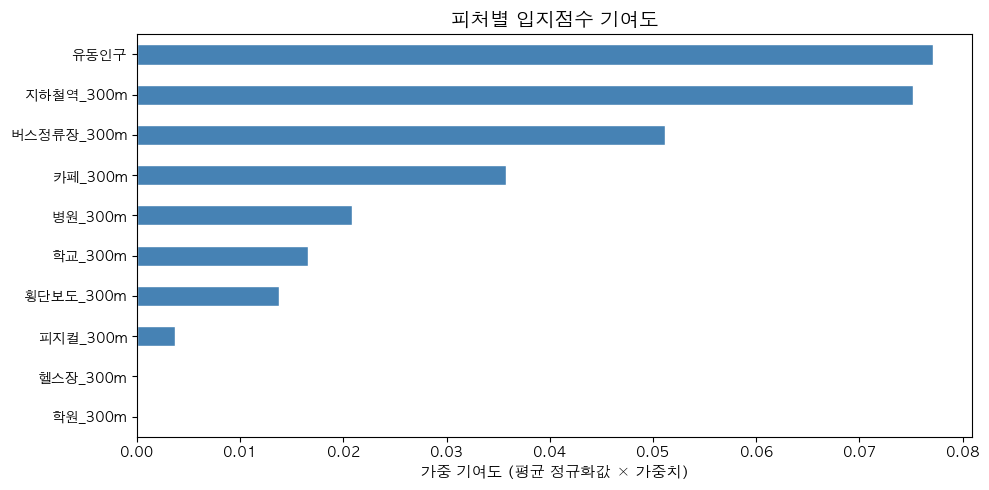

In [14]:
# 피처 중요도 
fig, ax = plt.subplots(figsize=(10, 5))

feat_means = {f: score_df[f'{f}_norm'].mean() * WEIGHTS.get(f, 0) for f in available_feats}
feat_df = pd.Series(feat_means).sort_values(ascending=True)

feat_df.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('가중 기여도 (평균 정규화값 × 가중치)', fontsize=11)
ax.set_title('피처별 입지점수 기여도', fontsize=14)
plt.tight_layout()
plt.savefig('./feature_contribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [17]:
# 지도 시각화 html
try:
    import folium
    from folium.plugins import MarkerCluster

    m = folium.Map(location=[37.56, 126.97], zoom_start=11, tiles='CartoDB positron')
    cluster = MarkerCluster().add_to(m)

    grade_colors = {'S': 'blue', 'A': 'green', 'B': 'orange', 'C': 'gray', 'D': 'red'}

    # 상위 300개만 지도에 표시
    top_listings = score_df.nlargest(300, '입지점수')

    for _, row in top_listings.iterrows():
        color = grade_colors.get(str(row.get('등급', 'C')), 'gray')
        popup_text = (
            f"점수: {row['입지점수']}점 ({row.get('등급','?')}등급)<br>"
            f"월세: {row.get('월세','?')}만원<br>"
            f"보증금: {row.get('보증금','?')}만원<br>"
            f"면적: {row.get('면적','?')}㎡"
        )
        folium.CircleMarker(
            location=[row['위도'], row['경도']],
            radius=6,
            color=color,
            fill=True,
            fill_opacity=0.8,
            popup=folium.Popup(popup_text, max_width=200)
        ).add_to(cluster)

    m.save('./banaresso_map.html')
    print('지도 저장 완료: banaresso_map.html')
    m

except ImportError:
    print('folium 미설치. 설치: pip install folium')

지도 저장 완료: banaresso_map.html


In [18]:
# 상위 10개 매물 출력 
display_cols = ['addr', '위도', '경도', '입지점수', '등급',
                '월세', '보증금', '면적', '환산보증금',
                '유동인구', '지하철역_300m', '버스정류장_300m', 'floor']
display_cols = [c for c in display_cols if c in score_df.columns]

top10 = score_df.nlargest(10, '입지점수')[display_cols]
print('입지점수 TOP 10 매물')
top10


입지점수 TOP 10 매물


,addr,위도,경도,입지점수,등급,월세,보증금,면적,환산보증금,유동인구,지하철역_300m,버스정류장_300m,floor
176,서울특별시 강남구 역삼동,37.505584,127.033875,65.1,B,2000000,20000000,82.64,220000000,20900630.0,1,9,2층
227,서울특별시 강남구 역삼동,37.505584,127.033875,65.1,B,2500000,20000000,82.60,270000000,20900630.0,1,9,2층
58,서울특별시 강남구 역삼동,37.505952,127.032884,64.2,B,1300000,10000000,66.12,140000000,20900630.0,1,10,지하1층
136,서울특별시 강남구 역삼동,37.505952,127.032884,64.2,B,1800000,20000000,68.40,200000000,20900630.0,1,10,5층
175,서울특별시 강남구 역삼동,37.505952,127.032884,64.2,B,1500000,20000000,66.12,170000000,20900630.0,1,10,5층
200,서울특별시 강남구 역삼동,37.505952,127.032884,64.2,B,1800000,20000000,66.12,200000000,20900630.0,1,10,5층
158,서울특별시 강남구 역삼동,37.506229,127.032763,63.4,B,1200000,20000000,49.60,140000000,20900630.0,1,10,3층
259,서울특별시 강남구 역삼동,37.506229,127.032763,63.4,B,1200000,20000000,52.89,140000000,20900630.0,1,10,3층
278,서울특별시 강남구 역삼동,37.506229,127.032763,63.4,B,1200000,20000000,52.89,140000000,20900630.0,1,10,3층
279,서울특별시 강남구 역삼동,37.506229,127.032763,63.4,B,950000,10000000,33.06,105000000,20900630.0,1,10,1층


In [19]:
# 결과 저장 
output_cols = display_cols + [f'{f}_norm' for f in available_feats]
output_cols = [c for c in output_cols if c in score_df.columns]

score_df[output_cols].to_csv('./banaresso_scored_listings.csv', index=False, encoding='utf-8-sig')
print('결과 저장 완료: banaresso_scored_listings.csv')
print(f'총 {len(score_df):,}개 매물에 입지점수 부여 완료')

결과 저장 완료: banaresso_scored_listings.csv
총 354개 매물에 입지점수 부여 완료
